In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split

project_root = Path.cwd().parent
data_path = project_root /"data" / "raw" / "complaints_processed.csv"

df = pd.read_csv(data_path)
df.head()


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [3]:
print(df.shape)
print(df.info())
df = df.dropna(subset=["narrative"])

(162421, 3)
<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  162421 non-null  int64
 1   product     162421 non-null  str  
 2   narrative   162411 non-null  str  
dtypes: int64(1), str(2)
memory usage: 97.3 MB
None


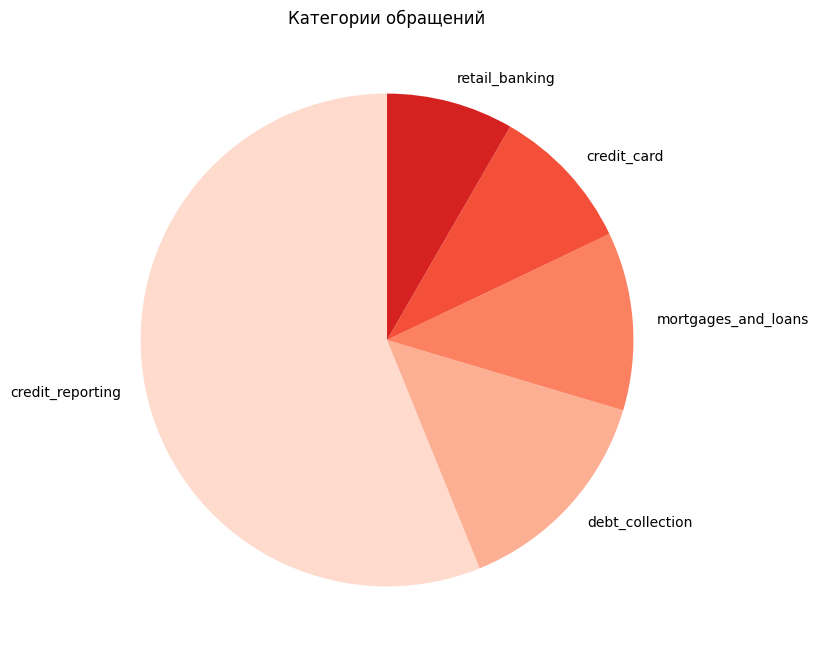

In [4]:
counts = df["product"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    counts,
    labels = counts.index,
    colors=sns.color_palette("Reds"),
    startangle=90
)
plt.title("Категории обращений")
plt.show()

классы разбалансированны

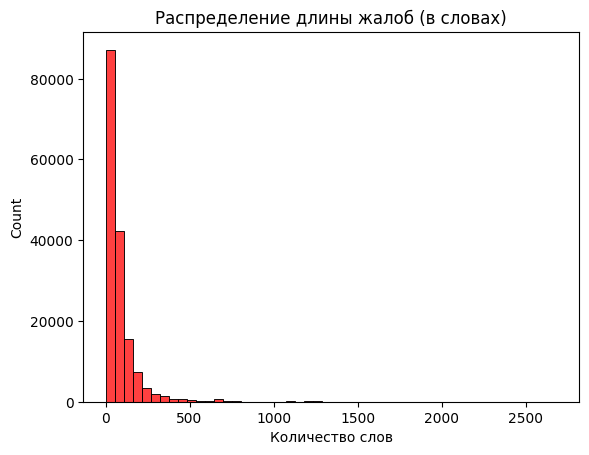

In [5]:
df["narrative_length"] = df["narrative"].str.split().str.len()
sns.histplot(df["narrative_length"], bins=50, color="Red")
plt.title("Распределение длины жалоб (в словах)")
plt.xlabel("Количество слов")
plt.show()

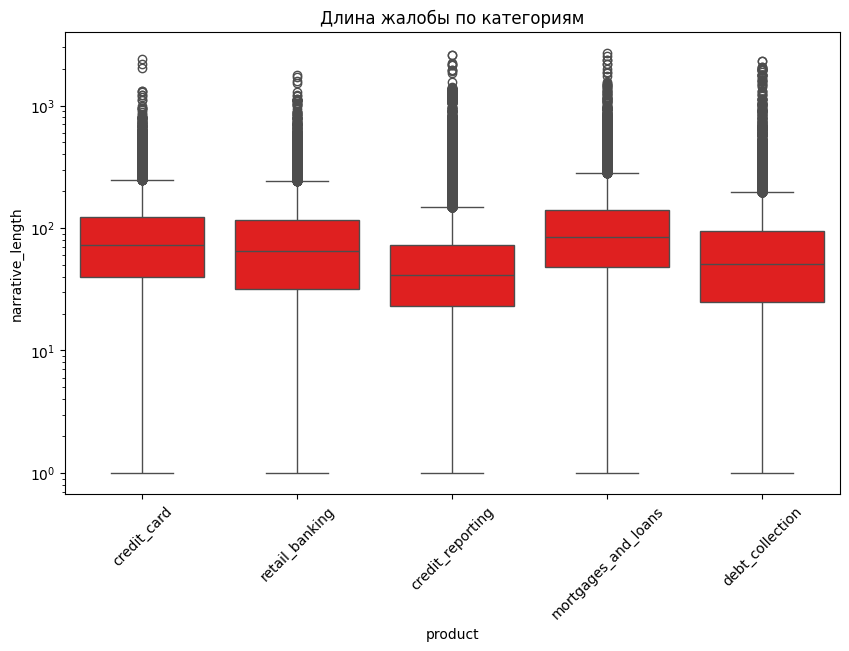

                       count        mean         std  min   25%   50%    75%  \
product                                                                        
credit_card          15566.0   98.166517   99.374742  1.0  40.0  72.0  123.0   
credit_reporting     91172.0   67.794103  103.210738  1.0  23.0  41.0   73.0   
debt_collection      23148.0   78.764472  110.476726  1.0  25.0  51.0   94.0   
mortgages_and_loans  18990.0  117.497420  129.441452  1.0  48.0  84.0  141.0   
retail_banking       13535.0   93.623125  105.813348  1.0  32.0  65.0  116.0   

                        max  
product                      
credit_card          2412.0  
credit_reporting     2568.0  
debt_collection      2325.0  
mortgages_and_loans  2685.0  
retail_banking       1777.0  


In [6]:
products = df.groupby("product")["narrative_length"].describe()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="product", y="narrative_length", color="Red")
plt.yscale("log")
plt.title("Длина жалобы по категориям")
plt.xticks(rotation=45)
plt.show()
print(products)

In [7]:
for product in df["product"].unique():
    print(product)
    print(df[df["product"]==product]["narrative"].sample(2, random_state=42).values)
    print()

credit_card
<ArrowStringArray>
['saturday make sevice appointment mother give credit card number company told time may allowed facility covid charge showed immediately pending surprise said would charged canceled immediately found would allowed canceled service call tentatively scheduled one week later saturday canceled email phone chat confirmed would charged charge went pending charge day canceling wednesday upon calling service company part citi visa informed would receive credit day disputing credit take long pay credit card full every month close next couple day pay interest charge allowed hit immediately undisputed credit allowed take day criminal scam service provider credit card company much legality delay', 'early opened dispute transaction citibank credit card dispute amount payment transporting automobile california iowa ultimately merchant never provided auto transport service citibank yet resolved dispute received phone call automobile transport company merchant merchant g

Очистка

In [8]:
def remove_mask(text):
    text = re.sub(r"x{2,}", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["narrative_clean"] = df["narrative"].apply(remove_mask)

In [9]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [10]:
df = df.drop_duplicates(subset="narrative", keep="first")

In [11]:
from tqdm import tqdm
texts = df["narrative_clean"].tolist()

lemmatized = []
for doc in tqdm(nlp.pipe(texts, batch_size=100), total=len(texts)):
    lemmatized.append(" ".join(token.lemma_ for token in doc))

df["narrative_clean"] = lemmatized
df["narrative_clean"].head()

100%|██████████| 124472/124472 [21:56<00:00, 94.53it/s] 


0    purchase order day shipping amount receive pro...
1    forward message date tue subject please invest...
2    forward message cc send friday pdt subject fin...
3    payment history miss credit report specialized...
4    payment history miss credit report make mistak...
Name: narrative_clean, dtype: str

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    df["narrative_clean"],
    df["product"],
    test_size=0.2,
    random_state= 42,
    stratify = df["product"]
)
print(y_train.value_counts(normalize=True))
y_test.value_counts(normalize=True)

product
credit_reporting       0.451831
debt_collection        0.169176
mortgages_and_loans    0.150416
credit_card            0.120369
retail_banking         0.108208
Name: proportion, dtype: float64


product
credit_reporting       0.451818
debt_collection        0.169150
mortgages_and_loans    0.150432
credit_card            0.120386
retail_banking         0.108215
Name: proportion, dtype: float64

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, min_df=5)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
vectorizer.get_feature_names_out()[:20]

(99577, 5000)
(24895, 5000)


array(['aa', 'aadvantage', 'aag', 'aargon', 'ab', 'abandon', 'abide',
       'ability', 'able', 'abroad', 'abruptly', 'absence', 'absent',
       'absolute', 'absolutely', 'absolve', 'absurd', 'abundance',
       'abuse', 'abusive'], dtype=object)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)


In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8509

                     precision    recall  f1-score   support

        credit_card       0.80      0.79      0.80      2997
   credit_reporting       0.87      0.90      0.88     11248
    debt_collection       0.81      0.74      0.77      4211
mortgages_and_loans       0.85      0.86      0.86      3745
     retail_banking       0.87      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.83      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



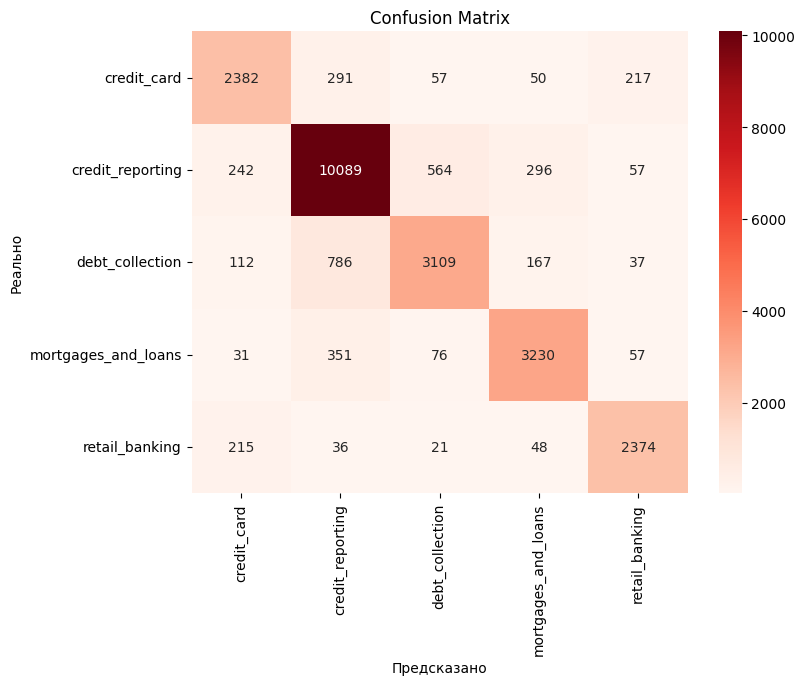

In [42]:
from sklearn.metrics import confusion_matrix


labels = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Reds")
plt.xlabel("Предсказано")
plt.ylabel("Реально")
plt.title("Confusion Matrix")
plt.show()

In [17]:
errors = X_test[y_test != y_pred]
error_true = y_test[y_test != y_pred]
error_pred = y_pred[y_test != y_pred]

for text, true_label, pred_label in list(zip(errors, error_true, error_pred))[:10]:
    print(f"РЕАЛЬНО: {true_label} | ПРЕДСКАЗАНО: {pred_label}")
    print(text[:200])
    print()

РЕАЛЬНО: mortgages_and_loans | ПРЕДСКАЗАНО: credit_reporting
original loan company buy buy onemain financial date original loan amount account number onemain report negative information credit report account charge account pay agree also pay full receive certif

РЕАЛЬНО: debt_collection | ПРЕДСКАЗАНО: credit_reporting
equifax show collection credit report client account go delinquency point within statute limitation fair credit reporting act receive communication year contact equifax recently claim verify debt mine

РЕАЛЬНО: credit_reporting | ПРЕДСКАЗАНО: debt_collection
enhance recovery report debt credit file owe recently check credit file notice debt call immediately pay debt never receive phone call collection notice letter pretty sure violate day right dispute

РЕАЛЬНО: credit_reporting | ПРЕДСКАЗАНО: debt_collection
year yell company credit card steal send account atty speak supposedly attorney state never get notice affidavit fill send police info give account hurt score tell p

у пары debt_collection/credit_reporting есть content overlap - это ограничение датасета, а не просто "модель недоучилась". Полностью убрать эту ошибку вряд ли получится улучшением модели - можно только снизить её.

In [18]:
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train_tfidf, y_train)
y_pred_balanced = model_balanced.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_balanced))


                     precision    recall  f1-score   support

        credit_card       0.73      0.84      0.78      2997
   credit_reporting       0.93      0.80      0.86     11248
    debt_collection       0.74      0.81      0.78      4211
mortgages_and_loans       0.79      0.89      0.84      3745
     retail_banking       0.83      0.90      0.86      2694

           accuracy                           0.83     24895
          macro avg       0.80      0.85      0.82     24895
       weighted avg       0.84      0.83      0.83     24895



общий F1 не улучшился

In [19]:
vectorizer_bigram = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    min_df = 5
    )

X_train_bigram = vectorizer_bigram.fit_transform(X_train)
X_test_bigram = vectorizer_bigram.transform(X_test)

model_bigram = LogisticRegression(max_iter=1000)
model_bigram.fit(X_train_bigram, y_train)
y_pred_bigram = model_bigram.predict(X_test_bigram)

print(classification_report(y_test, y_pred_bigram))

                     precision    recall  f1-score   support

        credit_card       0.81      0.79      0.80      2997
   credit_reporting       0.87      0.90      0.89     11248
    debt_collection       0.81      0.74      0.77      4211
mortgages_and_loans       0.85      0.86      0.86      3745
     retail_banking       0.87      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.84      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



не дало результата вероятно из-за того, что словарь забит одиночными словами


In [20]:
from sklearn.svm import LinearSVC

model_svc = LinearSVC(max_iter=2000)
model_svc.fit(X_train_tfidf, y_train)
y_pred_svc = model_svc.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svc))

                     precision    recall  f1-score   support

        credit_card       0.79      0.78      0.78      2997
   credit_reporting       0.88      0.89      0.88     11248
    debt_collection       0.80      0.74      0.77      4211
mortgages_and_loans       0.84      0.86      0.85      3745
     retail_banking       0.85      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.83      0.83      0.83     24895
       weighted avg       0.85      0.85      0.85     24895



опять нет результата

### Регуляция

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.1, 1, 10]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="f1_macro",
    cv = 3
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Лучший С: {grid_search.best_params_}")
print(f"Лучший макро F1 при кросс валидации: {grid_search.best_score_}")

Лучший С: {'C': 1}
Лучший макро F1 при кросс валидации: 0.8300373652363969


Значит дефолтное значение оптимально

In [22]:
feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(model.classes_):
    top_indices = model.coef_[i].argsort()[-15:][::-1]
    top_words = feature_names[top_indices]
    print(f"{class_label}: {', '.join(top_words)}")
    print()

credit_card: card, reliacard, reward, netspend, unemployment, merchant, credit, barclay, prepay, synchrony, interest, amex, mastercard, citi, prepaid

credit_reporting: equifax, experian, transunion, report, inquiry, trans, lexington, loan, lexisnexis, mortgage, remove, reporting, credit, score, bureau

debt_collection: debt, collection, collect, owe, recovery, credit, midland, convergent, call, report, llc, threaten, garnish, collector, medical

mortgages_and_loans: loan, mortgage, escrow, appraisal, principal, navient, closing, refinance, lending, loancare, pmi, chrysler, title, acceptance, newrez

retail_banking: fund, bank, money, transaction, branch, paypal, debit, deposit, coinbase, cd, pnc, provisional, bonus, checking, chime



Весьма осмысленный текст, классы путаются из-за как раз одинаковых слов

### Naive Bayes

In [23]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
y_pred_nb = model_nb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb))

                     precision    recall  f1-score   support

        credit_card       0.75      0.73      0.74      2997
   credit_reporting       0.83      0.89      0.86     11248
    debt_collection       0.82      0.62      0.71      4211
mortgages_and_loans       0.79      0.86      0.82      3745
     retail_banking       0.84      0.85      0.84      2694

           accuracy                           0.81     24895
          macro avg       0.81      0.79      0.79     24895
       weighted avg       0.81      0.81      0.81     24895



### Больше слов в словаре

In [24]:
vectorizer_large = TfidfVectorizer(max_features=20000, min_df=5)

X_train_large = vectorizer_large.fit_transform(X_train)
X_test_large = vectorizer_large.transform(X_test)

model_large = LogisticRegression(max_iter=1000)
model_large.fit(X_train_large, y_train)
y_pred_large = model_large.predict(X_test_large)

print(classification_report(y_test, y_pred_large))

                     precision    recall  f1-score   support

        credit_card       0.80      0.79      0.80      2997
   credit_reporting       0.87      0.90      0.89     11248
    debt_collection       0.82      0.74      0.78      4211
mortgages_and_loans       0.85      0.86      0.86      3745
     retail_banking       0.86      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.84      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



### Двухэтапная модель

In [25]:
import numpy as np

proba = model.predict_proba(X_test_tfidf)
classes = model.classes_

sorted_idx = np.argsort(proba, axis=1)
top1_idx = sorted_idx[:, -1]
top2_idx = sorted_idx[:, -2]

top1_class = classes[top1_idx]
top2_class = classes[top2_idx]

top1_proba = proba[np.arange(len(proba)), top1_idx]
top2_proba = proba[np.arange(len(proba)), top2_idx]

gap = top1_proba - top2_proba

In [26]:
pair = {"debt_collection", "credit_reporting"}

is_neponyatno = np.array([
    set([t1, t2]) == pair for t1, t2 in zip(top1_class, top2_class)
])

is_neponyatno = is_neponyatno & (gap < 0.3)

print(f"Спорных случаев: {is_neponyatno.sum()} из {len(is_neponyatno)}")

Спорных случаев: 1149 из 24895


In [27]:
y_pred = model.predict(X_test_tfidf)

wrong_in_neponyatno = (y_test[is_neponyatno] != y_pred[is_neponyatno]).sum()
total_wrong = (y_test != y_pred).sum()

print(f"Ошибок среди спорных случаев: {wrong_in_neponyatno} из {is_neponyatno.sum()}")
print(f"Всего ошибок на тесте: {total_wrong}")
print(f"Доля всех ошибок, приходящихся на спорные случаи: {wrong_in_neponyatno/total_wrong:.1%}")

Ошибок среди спорных случаев: 521 из 1149
Всего ошибок на тесте: 3711
Доля всех ошибок, приходящихся на спорные случаи: 14.0%


In [28]:
mask_train_pair = y_train.isin(["debt_collection", "credit_reporting"])

X_train_pair = X_train_tfidf[mask_train_pair.values]
y_train_pair = y_train[mask_train_pair]

model_judge = LogisticRegression(max_iter=1000)
model_judge.fit(X_train_pair, y_train_pair)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [29]:
X_test_neponyatno = X_test_tfidf[is_neponyatno]
y_pred_judge = model_judge.predict(X_test_neponyatno)

y_pred_final = y_pred.copy()
y_pred_final[is_neponyatno] = y_pred_judge

print(classification_report(y_test, y_pred_final))

                     precision    recall  f1-score   support

        credit_card       0.80      0.79      0.80      2997
   credit_reporting       0.87      0.90      0.88     11248
    debt_collection       0.81      0.73      0.77      4211
mortgages_and_loans       0.85      0.86      0.86      3745
     retail_banking       0.87      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.83      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



без изменений

In [30]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1)
model_rf.fit(X_train_tfidf, y_train)
y_pred_rf = model_rf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_rf))

                     precision    recall  f1-score   support

        credit_card       0.83      0.71      0.77      2997
   credit_reporting       0.83      0.95      0.89     11248
    debt_collection       0.87      0.67      0.76      4211
mortgages_and_loans       0.87      0.82      0.85      3745
     retail_banking       0.86      0.85      0.86      2694

           accuracy                           0.84     24895
          macro avg       0.85      0.80      0.82     24895
       weighted avg       0.85      0.84      0.84     24895



## Попробую подход через смысловую модель

In [32]:
import spacy
nlp_md = spacy.load("en_core_web_md", disable=["parser", "ner", "tagger", "attribute_ruler", "lemmatizer"])

In [33]:

all_words = set()
for text in df["narrative_clean"]:
    all_words.update(text.split())

print(f"Уникальных слов: {len(all_words)}")


word_to_vec = {}
for word in all_words:
    lex = nlp_md.vocab[word]
    if lex.has_vector:
        word_to_vec[word] = lex.vector

print(f"Слов с вектором: {len(word_to_vec)}")


def text_to_vector(text):
    vecs = [word_to_vec[w] for w in text.split() if w in word_to_vec]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(300)


X_train_emb = np.array([text_to_vector(t) for t in X_train])
X_test_emb = np.array([text_to_vector(t) for t in X_test])

print(X_train_emb.shape, X_test_emb.shape)

model_emb = LogisticRegression(max_iter=1000)
model_emb.fit(X_train_emb, y_train)
y_pred_emb = model_emb.predict(X_test_emb)

print(classification_report(y_test, y_pred_emb))

Уникальных слов: 40951
Слов с вектором: 26401
(99577, 300) (24895, 300)
                     precision    recall  f1-score   support

        credit_card       0.70      0.69      0.70      2997
   credit_reporting       0.83      0.87      0.85     11248
    debt_collection       0.74      0.62      0.68      4211
mortgages_and_loans       0.77      0.80      0.78      3745
     retail_banking       0.76      0.77      0.77      2694

           accuracy                           0.78     24895
          macro avg       0.76      0.75      0.75     24895
       weighted avg       0.78      0.78      0.78     24895



In [34]:
important_words = ["midland", "convergent", "navient", "loancare", "reliacard", "lexington", "lexisnexis", "netspend"]
for w in important_words:
    print(w, nlp_md.vocab[w].has_vector)
    

midland True
convergent True
navient False
loancare False
reliacard False
lexington True
lexisnexis True
netspend True


## Вывод
Изначальная модель использует как признаки названия колмпаний в тексте, которых нет в общем словаре смысловой модели, так что эффективность снижается

In [39]:
def predict_comp(text, vectorizer, model, nlp):
    text_clean = remove_mask(text)
    doc = nlp(text_clean)
    text_lemmatized = " ".join(token.lemma_ for token in doc)
    
    text_vec = vectorizer.transform([text_lemmatized])
    
    prediction = model.predict(text_vec)[0]
    proba = model.predict_proba(text_vec)[0]
    
    print(f"Предсказанная категория: {prediction}\n")
    print("Вероятности по всем классам:")
    for cls, p in sorted(zip(model.classes_, proba), key=lambda x: -x[1]):
        print(f"  {cls}: {p:.1%}")

In [41]:
predict_comp("I have got an issue and dont know what to do. Help me please!!! They keep calling me about a debt but I have already paid off and reported bruh", vectorizer, model, nlp)

Предсказанная категория: credit_reporting

Вероятности по всем классам:
  credit_reporting: 52.6%
  debt_collection: 30.0%
  mortgages_and_loans: 8.9%
  credit_card: 4.5%
  retail_banking: 4.0%


In [43]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(vectorizer, "models/vectorizer.joblib")
joblib.dump(model, "models/classifier.joblib")

print("Модель и векторайзер сохранены в models/")

Модель и векторайзер сохранены в models/
